In [1]:
#---------------library----------------
import numpy as np
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
#--------------Data_base---------------

data = fetch_california_housing(as_frame=True)
df = data.frame
small_df = df[["MedInc", "HouseAge", "MedHouseVal"]]

x0 = small_df["MedInc"].values
x1 = small_df["HouseAge"].values
y  = small_df["MedHouseVal"].values

#---------------formulas-----------------
def pred(x0,x1,w0,w1,b):
    y_pred = w0*x0 + w1*x1 + b
    print("pred_Y:", y_pred[:5])
    return y_pred

def error(x0,x1,y,w0,w1,b):
    j = np.mean((y - (w0*x0 + w1*x1 + b))**2)
    print("j(w0,w1,b):",j)
    return j
#---------------derivatives-------------
def derivative_w0(x0,x1,y,w0,w1,b):
    derivative = np.mean(-2*x0*(y-(w0*x0+w1*x1+b)))
    print("dw0:",derivative)
    return derivative

def derivative_w1(x0,x1,y,w0,w1,b):
    derivative = np.mean(-2*x1*(y-(w0*x0+w1*x1+b)))
    print("dw1:",derivative)
    return derivative

def derivative_b(x0,x1,y,w0,w1,b):
    derivative = np.mean(-2*(y-(w0*x0+w1*x1+b))) 
    print("db:",derivative)
    return derivative
#---------------------------------------

f = -0.1
l =  0.1

#---------------training----------------
def train_wb(w0=0.0,w1=0.0,b=0.0,number=0.001):

    while True:

        dw0 = derivative_w0(x0,x1,y,w0,w1,b)
        dw1 = derivative_w1(x0,x1,y,w0,w1,b)
        db  = derivative_b(x0,x1,y,w0,w1,b)

        if (f < dw0 < l) and (f < dw1 < l) and (f < db < l):
            break

        w0 -= number * dw0
        w1 -= number * dw1
        b  -= number * db

        print("w0:",w0," w1:",w1," b:",b)
        print("--------------------------------")

    print("Final W0:",w0)
    print("Final W1:",w1)
    print("Final B:",b)
    return w0,w1,b

W0,W1,B = train_wb()

error(x0,x1,y,W0,W1,B)
pred(x0,x1,W0,W1,B)
print("real_y:",y[:5])

print("The End_:)")

dw0: -19.030219731651165
dw1: -121.55271462790698
db: -4.137116338178294
w0: 0.019030219731651164  w1: 0.12155271462790698  b: 0.004137116338178294
--------------------------------
dw0: 7.966735769196077
dw1: 120.70019308464086
db: 2.980891977116577
w0: 0.011063483962455087  w1: 0.0008525215432661215  b: 0.001156224361061717
--------------------------------
dw0: -18.425742854370636
dw1: -117.42802701182647
db: -4.0003261179806575
w0: 0.029489226816825722  w1: 0.1182805485550926  b: 0.0051565504790423745
--------------------------------
dw0: 7.656679009886472
dw1: 116.61355784318948
db: 2.8764712845808367
w0: 0.021832547806939252  w1: 0.001666990711903113  b: 0.002280079194461538
--------------------------------
dw0: -17.840683755660102
dw1: -113.4432697363352
db: -3.868059444598904
w0: 0.03967323156259936  w1: 0.11511026044823831  b: 0.006148138639060443
--------------------------------
dw0: 7.358188691651236
dw1: 112.66532003398581
db: 2.7757014781698017
w0: 0.03231504287094812  w1: 0

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


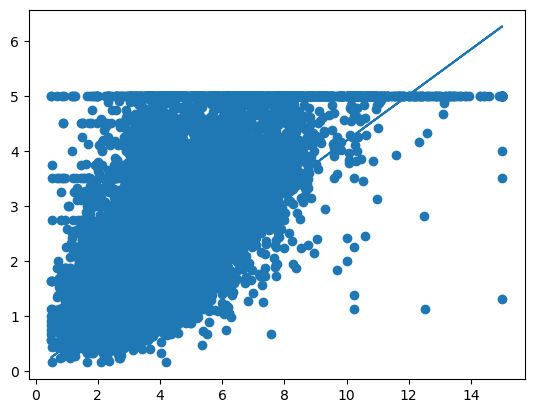

In [3]:
#-----mini_data_base------
mini_x0 = df[["MedInc"]]
mini_y = df[["MedHouseVal"]]
mini_x0.head(10)


plt.clf()
plt.scatter(mini_x0, mini_y)
plt.plot(mini_x0, W0*mini_x0 + B)
plt.show()

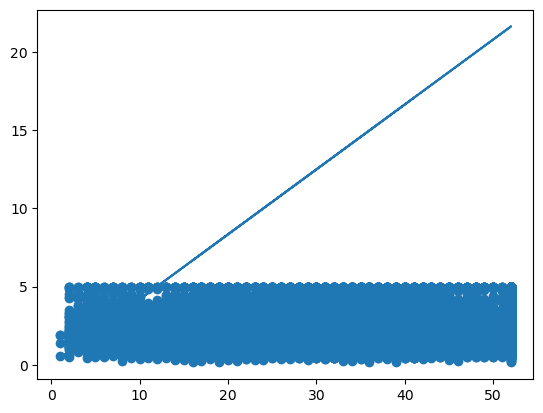

In [6]:
#-----mini_data_base------
mini_x1 = df[["HouseAge"]]
mini_y = df[["MedHouseVal"]]
mini_x1.head(10)


plt.clf()
plt.scatter(mini_x1, mini_y)
plt.plot(mini_x1, W0*mini_x1 + B)
plt.show()